# 05 · Ordinary differential equations

Three single equations: the forced oscillator, the Van der Pol oscillator and the
forced Duffing oscillator. Each section shows the data, the signal check at 0, 1
and 5 % noise, a search on clean data with the selected equation compared to the
record, and a search at 5 % noise.

**How to read the comparison.** The upper panel puts the left-hand side of the
selected equation, computed from the data, next to the value the equation
predicts from its right-hand side. For ordinary differential equations written
as "highest derivative = function of the state", the lower panel integrates the
equation from the first point of the record and compares the solution with the
data; there errors accumulate, so this is the stricter test. When the selected
equation is not of that form, only the upper panel is shown. A close match of the
two sides alone does not prove the law: an identity of the record or a rearranged
equation can match as well, so the set of terms is compared with the known law
separately.

Displayed outputs are saved examples from earlier executions and do not verify the current version. Re-execute the relevant cells to obtain current results. Searches may reuse a compatible saved run; the printed status identifies this. Recovered laws are established by the reported term comparison, rather than by the presence of a plotted equation.

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
from epde_bench.nbcache import cached_run, print_run
import epde_bench.nbcache as notebook_cache
if os.environ.get('EPDE_BENCH_NOTEBOOK_CACHE'):
    notebook_cache.CACHE_DIR = Path(os.environ['EPDE_BENCH_NOTEBOOK_CACHE'])
from epde_bench.env import seed_everything
seed_everything(0)
print('Search cache:', notebook_cache.CACHE_DIR)
from epde_bench.reconstruction import plot_reconstruction
%matplotlib inline
print('EPDE imported; notebook environment ready')

Search cache: <repo>/projects/pic/results/notebook_execution_2026-10-09/search_cache
EPDE imported; notebook environment ready


## Forced oscillator with time-dependent damping

$$u'' + \sin(2t)\,u' + 4u = 1.5\,t$$

ode: Forced oscillator with time-dependent damping
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (320,); variables: u
  t: [0, 15.95], 320 points
  truth:
    -4.0 * u{power: 1.0} + -1.0 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 1.5 * x{power: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' + sin(2t) u' + 4u = 1.5t on t in [0, 16), dt = 0.05.


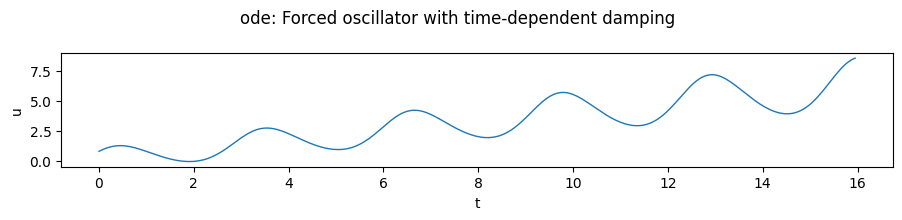

In [2]:
p = datasets.load('ode')
print(p.summary())
plot_problem(p); plt.show()

In [3]:
p, report = check('ode', noise_levels=[0, 1, 5])
print_check(p, report)

ode: Forced oscillator with time-dependent damping
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (320,); variables: u
  t: [0, 15.95], 320 points
  truth:
    -4.0 * u{power: 1.0} + -1.0 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 1.5 * x{power: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' + sin(2t) u' + 4u = 1.5t on t in [0, 16), dt = 0.05.

=== noise 0 % ===
R^2 of the true structure: 0.999831   (d^2u/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  u{'power': 1.0}                                                    -4      -3.9845            9.119e-01
  du/dx0{'power': 1.0} * sin{'power': 1.0, 'dim': 0.0, 'freq         -1     -0.98892            5.823e-02
  x{'power': 1.0, 'dim': 0.0}                                       1.5       1.4974            5.044e-01

=== noise 1 % ===
R^2 of the true structure: 0.433371   (d^2u/dx0^2{power: 1.0})
  term            

In [4]:
rec = cached_run('ode', variant='default', noise=0.0, seed=0)
print_run(rec)

ok fit 16 s (from cache)
[0] <- compromise pick
     -3.98448568355491 * u{power: 1.0} + 1.4969734589992256 * x{power: 1.0, dim: 0.0} + -0.9885206385764272 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = d^2u/dx0^2{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'coef_error': 0.005791878178453848}


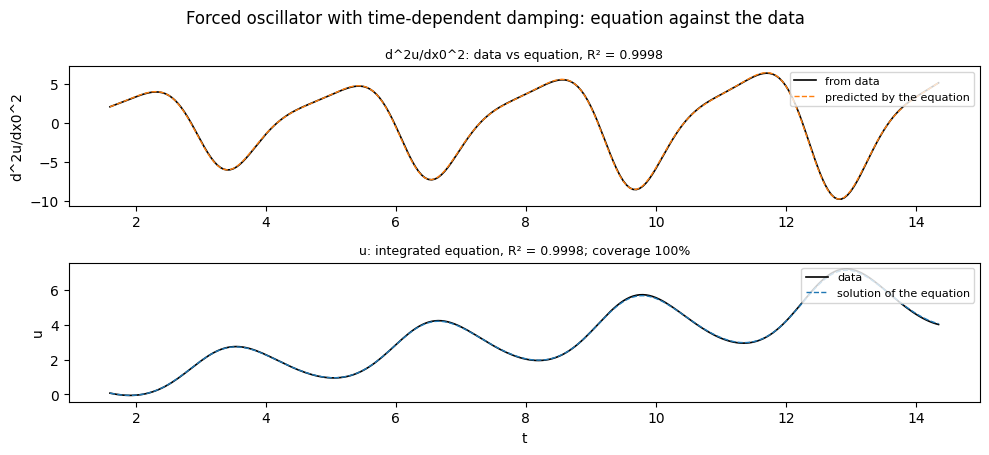

{'d^2u/dx0^2{power: 1.0}': 0.9998, 'trajectory u': 0.9998}


In [5]:
problem = datasets.load('ode')
search_cfg = resolve_for_problem(load_config('ode'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

In [6]:
rec = cached_run('ode', variant='default', noise=5.0, seed=0)
print_run(rec)

Set self._mem_for_cache as 2
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11efb6f90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11efb6f90>
Set domain <epde.structure.domain.Domain object at 0x11f022f90> with inner shape of [256]
Deriv orders after definition [[0], [0, 0]]
Added trajectory 0 to exist. traj: dict_keys([])
The cardinality of defined token pool is [1 2 1 2]
Among them, the pool contains [1 2 1]
No x data in cache for constancy check. Functionality of eval-d token check TBD.
No sin data in cache for constancy check. Functionality of eval-d token check TBD.
No cos data in cache for constancy check. Functionality of eval-d token check TBD.
self.vars_demand_equation {'u'}
[0.60546246 0.19886518]
[0.99605588 0.38711597]
[0.99792403 0.32220688]
[0.99705165 0.39859273]
[0.84432907 0.43576836]
[0.98583594 0.21102403]
[0.98494824 0.0158158 ]


[8.12324188e-01 5.18701612e-04]
[0.70692357 0.1831106 ]
[0.99560889 0.53371543]


[0.81933493 0.05954856]
[0.97835948 0.78089816]
[0.85585483 0.18462388]
[0.84946176 0.28398469]
[0.90595909 0.40379136]
[0.60099537 0.60177795]
[0.62415455 0.17315785]
[0.632318   0.10477273]
[0.74226679 0.10144589]
[0.97783341 0.03048109]
[0.91327838 0.27694313]
[0.68830377 0.38435454]
[0.97767709 0.03875545]


[0.61167278 0.06622941]


[0.53945418 0.0453371 ]
[0.77906014 0.03822766]
[0.87871051 0.02233946]
[0.67667817 0.01146213]
[0.87404616 0.00937738]
[0.60696437 0.26183444]
[0.97895584 0.01067999]
[0.77391132 0.36805496]


...

[0.57425734 0.10458239]
[0.65816555 0.09739997]


[0.6177187  0.47397205]
[0.62642471 0.03923435]
[0.78031952 0.13726171]
[0.60955285 0.05179784]


[0.80249556 0.0410032 ]
[0.78807114 0.0698379 ]
[0.88485183 0.46250222]
[0.70726425 0.26250281]
[0.95214815 0.26430854]
[0.69178505 1.23186765]


[0.80602277 0.39701028]
[0.57200965 0.08214182]
[0.99743668 0.5251583 ]
[0.79188589 0.19525628]
[0.66763519 0.09487615]
[0.61281445 0.0877966 ]


[0.6971062  0.18478584]
[0.69407271 0.11213831]
[0.82439255 0.49383229]
[0.68408886 0.34584033]
The optimization has been conducted.
ok fit 15 s 
[0] <- compromise pick
     0.37767192629052476 * du/dx0{power: 1.0} * x{power: 1.0, dim: 0.0} + -0.026752185511043487 * u{power: 3.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.015931012500262184 * u{power: 3.0} + 0.0 = du/dx0{power: 1.0} * u{power: 1.0}
[1]
     2.2962678874080824 * u{power: 1.0} * d^2u/dx0^2{power: 1.0} + 24.55562608131559 * u{power: 2.0} + -20.573826506852207 * u{power: 1.0} * x{power: 1.0, dim: 0.0} + 4.1782854405168415 * x{power: 2.0, dim: 0.0} + 0.0 = d^2u/dx0^2{power: 1.0} * x{power: 1.0, dim: 0.0}
{'front_size': 2, 'selected_index': 0, 'success_front': False, 'success_selected': False, 'hamming_min': 8, 'hamming_selected': 8, 'coef_error': None}


## Van der Pol oscillator

$$u'' = 0.2\,(1 - u^2)\,u' - u$$

vdp: Van der Pol oscillator (mu = 0.2)
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (320,); variables: u
  t: [0, 15.95], 320 points
  truth:
    -0.2 * u{power: 2.0} * du/dx0{power: 1.0} + 0.2 * du/dx0{power: 1.0} + -1.0 * u{power: 1.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' = 0.2 (1 - u^2) u' - u on t in [0, 16), dt = 0.05.


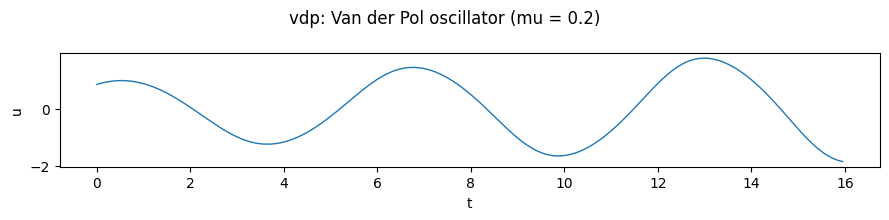

In [7]:
p = datasets.load('vdp')
print(p.summary())
plot_problem(p); plt.show()

In [8]:
p, report = check('vdp', noise_levels=[0, 1, 5])
print_check(p, report)

vdp: Van der Pol oscillator (mu = 0.2)
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (320,); variables: u
  t: [0, 15.95], 320 points
  truth:
    -0.2 * u{power: 2.0} * du/dx0{power: 1.0} + 0.2 * du/dx0{power: 1.0} + -1.0 * u{power: 1.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' = 0.2 (1 - u^2) u' - u on t in [0, 16), dt = 0.05.

=== noise 0 % ===
R^2 of the true structure: 1.000000   (d^2u/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx0{'power': 1.0} * u{'power': 2.0}                           -0.2     -0.19902            1.745e-02
  du/dx0{'power': 1.0}                                              0.2      0.19933            1.975e-02
  u{'power': 1.0}                                                    -1     -0.99957            9.775e-01

=== noise 1 % ===
R^2 of the true structure: 0.142966   (d^2u/dx0^2{power: 1.0})
  term                                                      

In [9]:
rec = cached_run('vdp', variant='default', noise=0.0, seed=0)
print_run(rec)

Set self._mem_for_cache as 2
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11f563750>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11f563750>
Set domain <epde.structure.domain.Domain object at 0x11f5a1a90> with inner shape of [256]
Deriv orders after definition [[0], [0, 0]]
Added trajectory 0 to exist. traj: dict_keys([])
The cardinality of defined token pool is [1 2 1 2]
Among them, the pool contains [1 2 1]
No x data in cache for constancy check. Functionality of eval-d token check TBD.
No sin data in cache for constancy check. Functionality of eval-d token check TBD.
No cos data in cache for constancy check. Functionality of eval-d token check TBD.
self.vars_demand_equation {'u'}


[1.53460708e-04 8.61991957e-06]
[0.73023361 1.13046776]
[0.13619265 0.00217553]
[0.4068298  0.26921407]
[0.6783907  0.07158498]


[0.80333135 0.09513007]
[0.36556484 0.58253185]
[0.23509224 0.00833397]
[0.1193196 0.0656274]


[0.07841419 0.05115169]


[0.94059453 0.25466873]
[0.39636832 0.55005683]


...

Could not generate unique offspring
Could not generate unique offspring


Could not generate unique offspring
Could not generate unique offspring


Could not generate unique offspring
Could not generate unique offspring


Could not generate unique offspring
Could not generate unique offspring


Could not generate unique offspring
Could not generate unique offspring
Could not generate unique offspring
[0.95723506 0.56302082]
The optimization has been conducted.
ok fit 32 s 
[0] <- compromise pick
     0.19932724586034573 * du/dx0{power: 1.0} + -0.1990215657127575 * du/dx0{power: 1.0} * u{power: 2.0} + -0.9995698877465787 * u{power: 1.0} + 0.0 = d^2u/dx0^2{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'coef_error': 0.0028953514626350783}


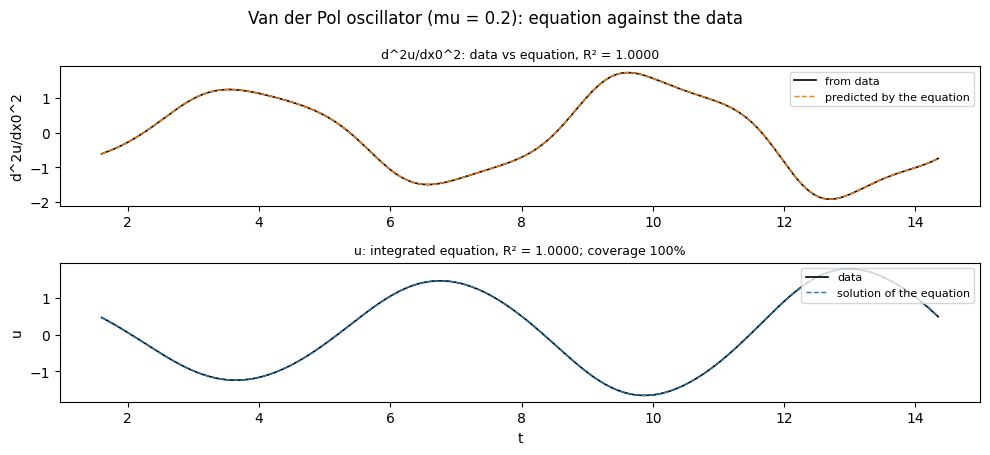

{'d^2u/dx0^2{power: 1.0}': 1.0, 'trajectory u': 1.0}


In [10]:
problem = datasets.load('vdp')
search_cfg = resolve_for_problem(load_config('vdp'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

In [11]:
rec = cached_run('vdp', variant='default', noise=5.0, seed=0)
print_run(rec)

Set self._mem_for_cache as 2
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11f5a1a90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11f5a1a90>
Set domain <epde.structure.domain.Domain object at 0x11f454b90> with inner shape of [256]
Deriv orders after definition [[0], [0, 0]]
Added trajectory 0 to exist. traj: dict_keys([])
The cardinality of defined token pool is [1 2 1 2]
Among them, the pool contains [1 2 1]
No x data in cache for constancy check. Functionality of eval-d token check TBD.
No sin data in cache for constancy check. Functionality of eval-d token check TBD.
No cos data in cache for constancy check. Functionality of eval-d token check TBD.
self.vars_demand_equation {'u'}
[0.99324087 0.23963641]


[0.99735566 0.32517847]
[0.99456086 0.40355744]
[0.99103818 0.38697096]
[0.99950319 0.88765583]
[0.98456208 0.09834805]
[0.84192407 0.52728124]
[0.98681261 0.27420639]
[0.99828173 0.51983668]
[0.95250665 0.23170758]
[0.90683235 0.06833301]
[0.97225295 0.23661148]
[0.93903054 0.33918825]
[0.91163452 0.20118587]


[0.85607739 0.4331302 ]
[0.8430438  0.11334924]


[0.85555768 0.8865856 ]
[0.83925851 0.36030232]
[0.90220889 0.39643942]
[0.98747257 0.75910687]
[0.90595173 0.1814809 ]
[0.93004394 0.18246632]


[0.77462486 0.03086923]


...

Could not generate unique offspring
Could not generate unique offspring
[0.9559501  0.36923308]


Could not generate unique offspring
Could not generate unique offspring


Could not generate unique offspring
Could not generate unique offspring


Could not generate unique offspring
[0.88772492 0.20264629]


Could not generate unique offspring
Could not generate unique offspring
The optimization has been conducted.
ok fit 31 s 
[0]
     0.10758555645810124 * x{power: 1.0, dim: 0.0} * cos{power: 1.0, freq: 2.0, dim: 0.0} + -0.08397142485412876 * x{power: 1.0, dim: 0.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = du/dx0{power: 1.0} * u{power: 1.0}
[1]
     0.1005516818435371 * u{power: 2.0} * x{power: 1.0, dim: 0.0} + -0.1919939301089805 * x{power: 1.0, dim: 0.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + -0.012609848342927641 * x{power: 2.0, dim: 0.0} + 0.0 = u{power: 1.0} * du/dx0{power: 1.0}
[2] <- compromise pick
     0.00895608186282935 * x{power: 2.0, dim: 0.0} + -0.0055649325406030336 * x{power: 2.0, dim: 0.0} * u{power: 2.0} + 0.16440101294320794 * x{power: 1.0, dim: 0.0} * cos{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = u{power: 1.0} * du/dx0{power: 1.0}
{'front_size': 3, 'selected_index': 2, 'success_front': False, 'success_selected': False, 'hamming_min': 7, 'hamming_selected': 8, '

## Forced Duffing oscillator

$$u'' + 0.2\,u' + u + u^3 = 0.3\cos t$$

The parameters are stored in the data file.

duffing: Forced Duffing oscillator
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (1001,); variables: u
  t: [0, 20], 1001 points
  truth:
    -0.20000000298023224 * du/dx0{power: 1.0} + -1.0 * u{power: 1.0} + -1.0 * u{power: 3.0} + 0.30000001192092896 * cos{power: 1.0, freq: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' + delta u' + alpha u + beta u^3 = gamma cos(omega t); the parameters are stored in the data file.


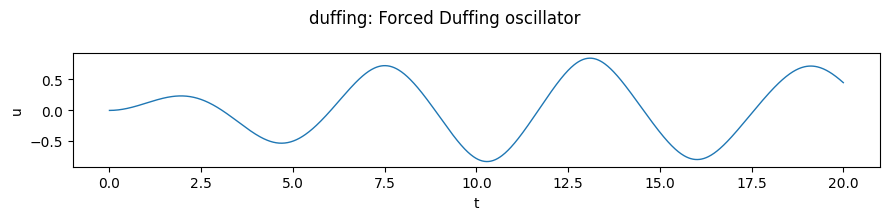

In [12]:
p = datasets.load('duffing')
print(p.summary())
plot_problem(p); plt.show()

In [13]:
p, report = check('duffing', noise_levels=[0, 1, 5])
print_check(p, report)

duffing: Forced Duffing oscillator
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (1001,); variables: u
  t: [0, 20], 1001 points
  truth:
    -0.20000000298023224 * du/dx0{power: 1.0} + -1.0 * u{power: 1.0} + -1.0 * u{power: 3.0} + 0.30000001192092896 * cos{power: 1.0, freq: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' + delta u' + alpha u + beta u^3 = gamma cos(omega t); the parameters are stored in the data file.

=== noise 0 % ===
R^2 of the true structure: 1.000000   (d^2u/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx0{'power': 1.0}                                             -0.2     -0.19988            1.137e-02
  u{'power': 1.0}                                                    -1      -1.0003            9.384e-02
  u{'power': 3.0}                                                    -1     -0.99866            2.239e-02
  cos{'power': 1.0, 'dim': 0.0, 'freq': 1.0

In [14]:
rec = cached_run('duffing', variant='default', noise=0.0, seed=0)
print_run(rec)

Set self._mem_for_cache as 2
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11f2f0180>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11f2f0180>
Set domain <epde.structure.domain.Domain object at 0x11f2f3950> with inner shape of [801]
Deriv orders after definition [[0], [0, 0]]
Added trajectory 0 to exist. traj: dict_keys([])
The cardinality of defined token pool is [1 2 1 2]
Among them, the pool contains [1 2 1 2]
No x data in cache for constancy check. Functionality of eval-d token check TBD.
No sin data in cache for constancy check. Functionality of eval-d token check TBD.
No cos data in cache for constancy check. Functionality of eval-d token check TBD.
self.vars_demand_equation {'u'}
[0.45860608 0.05807408]
[0.32668992 0.25249649]


[0.21444012 0.07543429]
[2.66715055e-04 1.97633655e-06]
[0.67299577 0.44501309]
[0.46573581 0.93540291]
[0.13949701 0.02219191]
[0.28542772 0.37600083]
[0.44671169 0.22452805]


<repo>/projects/pic/epde_bench/runner.py:43: EPDEUsageWarning: Axis 0 is not uniformly sampled (step varies by 1.907e-06 about 2.000e-02). The least-squares measure is an index-space sum with no cell-volume weighting, so densely sampled regions dominate the fit; SpectralDeriv also assumes uniform spacing. Pass a quadrature weight via createDomain(gfunction=...) if that is not what you want.
  _, domain = search.createDomain(list(problem.grids), ID=0)


[0.77058822 0.78696852]
[0.27652619 0.07810319]


[0.31605895 0.19125626]
[0.43963303 2.86883194]


...

Could not generate unique offspring
Could not generate unique offspring


Could not generate unique offspring
[0.06753467 0.0599086 ]
Could not generate unique offspring


Could not generate unique offspring
Could not generate unique offspring
Could not generate unique offspring


[0.17092689 0.21222215]
Could not generate unique offspring


Could not generate unique offspring
Could not generate unique offspring
[0.18693197 0.16637061]
The optimization has been conducted.
ok fit 31 s 
[0] <- compromise pick
     0.29983285657910047 * cos{power: 1.0, freq: 1.0, dim: 0.0} + -0.19988944018427807 * du/dx0{power: 1.0} + -1.0002512960696779 * u{power: 1.0} + -0.9986763439179497 * u{power: 3.0} + 0.0 = d^2u/dx0^2{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'coef_error': 0.0006712376434706471}


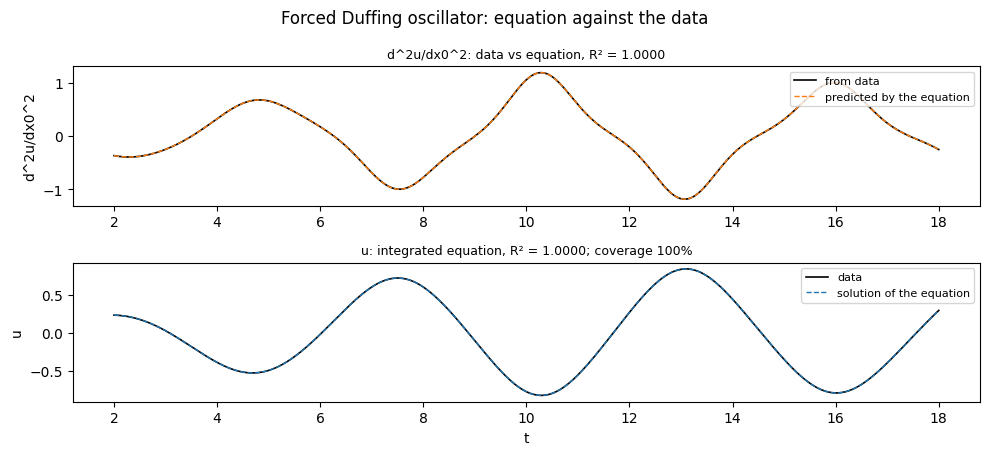

{'d^2u/dx0^2{power: 1.0}': 1.0, 'trajectory u': 1.0}


In [15]:
problem = datasets.load('duffing')
search_cfg = resolve_for_problem(load_config('duffing'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

In [16]:
rec = cached_run('duffing', variant='default', noise=5.0, seed=0)
print_run(rec)

Set self._mem_for_cache as 2
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11f2f3bb0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11f2f3bb0>
Set domain <epde.structure.domain.Domain object at 0x11f629940> with inner shape of [801]
Deriv orders after definition [[0], [0, 0]]
Added trajectory 0 to exist. traj: dict_keys([])
The cardinality of defined token pool is [1 2 1 2]
Among them, the pool contains [1 2 1 2]
No x data in cache for constancy check. Functionality of eval-d token check TBD.
No sin data in cache for constancy check. Functionality of eval-d token check TBD.
No cos data in cache for constancy check. Functionality of eval-d token check TBD.
self.vars_demand_equation {'u'}
[0.99825865 0.51341412]
[0.99797514 0.77925665]
[0.99860498 0.17352944]
[0.99383562 0.16055562]
[0.90158684 0.44692964]


<repo>/projects/pic/epde_bench/runner.py:43: EPDEUsageWarning: Axis 0 is not uniformly sampled (step varies by 1.907e-06 about 2.000e-02). The least-squares measure is an index-space sum with no cell-volume weighting, so densely sampled regions dominate the fit; SpectralDeriv also assumes uniform spacing. Pass a quadrature weight via createDomain(gfunction=...) if that is not what you want.
  _, domain = search.createDomain(list(problem.grids), ID=0)


[0.99691368 0.3120324 ]
[0.83949684 0.71865499]


[0.94613735 0.76109138]
[0.99581839 0.17580586]
[0.99868843 0.7040323 ]


[0.91500349 2.67804847]


...

[0.97509318 0.65719489]


Could not generate unique offspring


Could not generate unique offspring


Could not generate unique offspring


Could not generate unique offspring
The optimization has been conducted.
ok fit 73 s 
[0]
     0.1260607469752654 * cos{power: 1.0, freq: 1.0, dim: 0.0} * x{power: 1.0, dim: 0.0} + -0.009746865215339101 * x{power: 2.0, dim: 0.0} * u{power: 1.0} + 0.0 = du/dx0{power: 1.0}
[1] <- compromise pick
     -1.0602014002189522 * u{power: 1.0} * sin{power: 1.0, freq: 1.0, dim: 0.0} + 1.785292535867542 * du/dx0{power: 1.0} * u{power: 3.0} + -2.8371798325433346 * cos{power: 1.0, freq: 1.0, dim: 0.0} * u{power: 3.0} + 2.5455207540973213 * u{power: 2.0} + 0.0 = cos{power: 1.0, freq: 1.0, dim: 0.0} * du/dx0{power: 1.0}
[2]
     1.4233321830923285 * cos{power: 1.0, freq: 1.0, dim: 0.0} * u{power: 3.0} + 0.4968117655250844 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 1.0, dim: 0.0} + 0.026803524407900074 * x{power: 1.0, dim: 0.0} + -0.10303635730742058 * x{power: 1.0, dim: 0.0} * u{power: 2.0} + 0.0 = u{power: 1.0} * du/dx0{power: 1.0}
{'front_size': 3, 'selected_index': 1, 'success_front': False, 'suc

## Forecast on an unseen interval

Discovery uses the first 70% of the trajectory. Candidate selection uses only training derivatives. The selected equation is frozen before forecasting the final 30%, with initial conditions estimated from the training endpoint. Good prediction does not guarantee exact recovery of the true equation; inspect the selected terms as well as the errors.

Set self._mem_for_cache as 2
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11daaee40>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11daaee40>
Set domain <epde.structure.domain.Domain object at 0x11dcd96a0> with inner shape of [180]
Deriv orders after definition [[0], [0, 0]]
Added trajectory 0 to exist. traj: dict_keys([])
The cardinality of defined token pool is [1 2 1 2]
Among them, the pool contains [1 2 1]
No x data in cache for constancy check. Functionality of eval-d token check TBD.
No sin data in cache for constancy check. Functionality of eval-d token check TBD.
No cos data in cache for constancy check. Functionality of eval-d token check TBD.
self.vars_demand_equation {'u'}
[0.2131601  0.00775583]
[0.79974026 0.17057698]
[0.75401075 0.22939305]
[0.8235444  0.21607925]
[0.76735324 0.17046721]
[0.64090736 0.0315174 ]
[0.59881355 0.00760358]


[0.30007265 0.00181942]
[0.10471032 0.01116018]
[0.33147242 0.01968012]
[0.30126734 0.07028751]
[0.23604808 0.00789312]


[0.32616937 0.11355838]
[0.30891119 0.01955774]
[0.83652338 0.05410142]
[0.30659053 0.28613521]


[0.36349916 0.04133121]
[0.71006034 0.01579089]
[0.29431504 0.37389377]
[0.15030919 0.10204486]


[0.36023314 0.14646303]


...

[0.25470231 0.08029006]
[0.10195478 0.02169766]


[0.11998915 0.03525035]
[0.31909364 0.46965252]


[0.38453193 0.03997033]
[0.20158804 0.01762305]
[0.23451328 0.01281414]
[0.18100127 0.01430952]


[0.52465241 0.19243185]
The optimization has been conducted.


Status: ok
Training: {'n_points': 224, 'time_range': [0.0, 11.15], 'data_sha256': 'c89f495def6bbfcff4ff17144c6ca67feba732b82b91c3f6f4289c5544e92508', 'derivative_r2': 0.9999806660792105, 'integration_success': True, 'coverage': 1.0, 'metrics': {'u': {'rmse': 0.013632543743436195, 'mae': 0.009535346504356116, 'r2': 0.9999214238341396}}}
Held-out: {'n_points': 96, 'time_range': [11.200000000000001, 15.950000000000001], 'integration_success': True, 'coverage': 1.0, 'message': 'The solver successfully reached the end of the integration interval.', 'metrics': {'u': {'rmse': 0.01992835372894183, 'mae': 0.014939868267107281, 'r2': 0.9998324293217595}}}
Selected equation: ['0.017647649750561357 * du/dx0{power: 2.0} + 1.4954740019828381 * x{dim: 0.0, power: 1.0} + -3.9939040258839977 * u{power: 1.0} + -0.94809338670441401 * du/dx0{power: 1.0} * sin{dim: 0.0, freq: 2.0, power: 1.0} + 0 = d^2u/dx0^2{power: 1.0}']
Selection rule: minimum relative derivative MSE on training interior; ties by Pareto

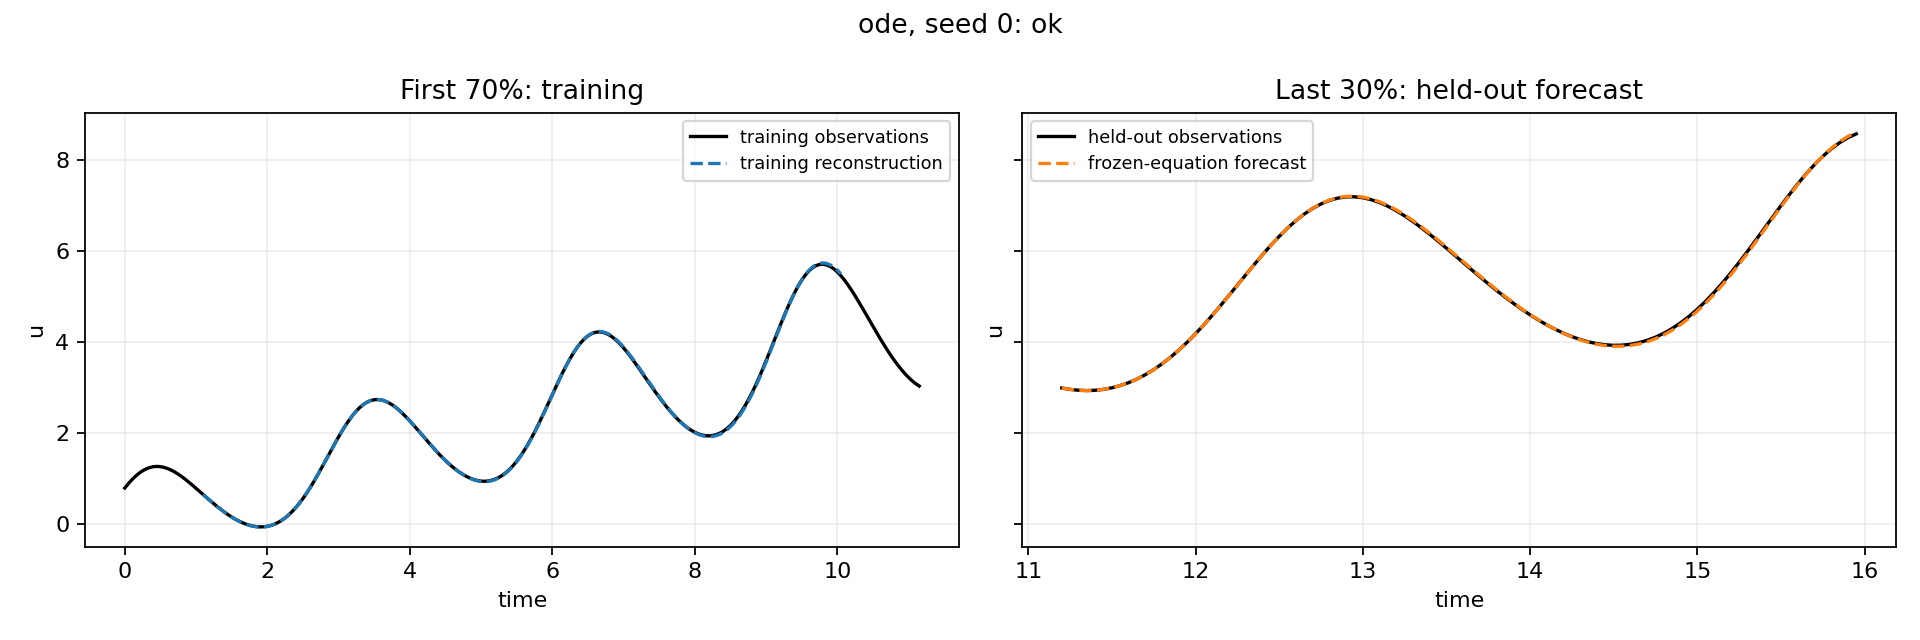

In [17]:
from epde_bench.heldout import run_heldout
from IPython.display import Image, display
heldout_dir = notebook_cache.CACHE_DIR.parent / 'heldout_ode'
heldout = run_heldout('ode', train_fraction=0.7, seed=0, output_dir=heldout_dir)
print('Status:', heldout['status'])
print('Training:', heldout['train'])
print('Held-out:', heldout['test'])
print('Selected equation:', heldout.get('selected'))
print('Selection rule:', heldout.get('selection_rule'))
display(Image(filename=str(heldout_dir / 'trajectory.png')))
assert heldout['status'] == 'ok', heldout.get('error', heldout.get('reason'))